# **Analyse Prédictive du Risque de Défaut de Paiement par Cartes de Crédit : Approche Comparative de 4 modèles en Machine Learning**

**Résumé** : Ce projet vise à étudir et à anticiper le risque de défaut de paiement des clients d'une institution financière, en utilisant un ensemble de données de **30000 individus**.
L'étude s'appuie sur 23 variables explicatives, nommée de (X1 à X23) initialement, et couvrant le profil démographique (âge, sexe, éducation), l'historique des paiements et l'état des factures sur une période de six mois (entre avril et septembre 2005).

Etant apprenti en science des données, l'approche pour répondre à la problématique des défaut de crédit s'est faite en quatre étapes:

**Harmonisation de la base de donnée** : Il a été procédé dans un premier temps une harmonisation des intitulés pour éviter toute confusion dans le traitement, nous avons par la suite mis à jour les formats des colonnes, notemment en transformant en binaire celles les variables qui devraient l'être (sexe , ...).

**Exploration Statistique** : Dans un premier temps, il a été fait des visualisations pour mieux comprendre le jeu de données ainsi que l'enjeu sur chaque variable, par la suite,nous avons procédé à l'identification du déséquilibre des classes (22% de défauts contre 78% de non défaut). Les corrélations entre les retards de paiement passés nous permettent également de mieux cerner le risque futur, celui que nous estimons dans cette présente étude.

**Modélisation** : Entraînement comparatif de quatre familles d'algorithmes (**Régression Logistique**, **Random Forest**, **Réseaux de Neurones** et **XGBoost**).

**Optimisation** : Amélioration du modèle champion que nous avons retenu grâce à la sélection, en faisant un focus sur le F1-Score.
L'amélioration a été faite via une recherche d'hyperparamètres (**GridSearchCV**) pour garantir la fiabilité des prédictions.

In [ ]:
# Configuration de l'environnement de travail
# Les packages essentiels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Outils de préparation et de pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modèles (les 4 familles de modèles que nous avons traité)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Métriques d'évaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)

# Configuration visuelle
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Étape de configuration ok : Environnement configuré.")

Étape de configuration ok : Environnement configuré.


# 1. Importation et Formattage de la base de données

In [ ]:
# Lien sur lequel nous avons hébergé la base, pour la rendre accessible à l'ensemble du groupe sans ambiguité
url = "https://github.com/ygoubgou/classification/raw/master/BDD/default_of_credit_card_clients.xls"

# Chargement de la base
df = pd.read_excel(url, skiprows=1)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
raw_df = df.copy()

# Renaming and Reformating variables
raw_df.columns = raw_df.columns.str.lower().str.replace(' ', '_')

months = ["sep", "aug", "jul", "jun", "may", "apr"]
variables = ["payment_status", "bill_statement", "previous_payment"]
new_col_names = [x + '_' + y for x in variables for y in months]
rename_dict = {x : y for x, y in zip(raw_df.loc[:,'pay_0':'pay_amt6'].columns, new_col_names)}
raw_df.rename(columns=rename_dict, inplace=True)

# Mapping Categorial Variables
gender_dict = {1:"Male", 2:"Female"}
education_dict = {0: "Others", 1: "Graduate School", 2:"University", 3:"High School", 4:"Others", 5:"Others", 6:"Others"}
marital_status_dict = {0:'Others', 1:'Married', 2:'Single', 3:'Others'}
payment_status = {-2:'Inactive', -1:"Payed Duly", 0:'Credit Revolving', 1:'Payment Delayed 1 mth',
                  2:'Payment Delayed 2 mth',
                  3:'Payment Delayed 3 mth',
                  4:'Payment Delayed 4 mth',
                  5:'Payment Delayed 5 mth',
                  6:'Payment Delayed 6 mth',
                  7:'Payment Delayed 7 mth',
                  8:'Payment Delayed 8 mth',
                  9:'Payment Delayed >= 9 mth'}
raw_df["sex"] = raw_df["sex"].map(gender_dict)
raw_df["education"] = raw_df["education"].map(education_dict)
raw_df["marriage"] = raw_df["marriage"].map(marital_status_dict)


cat_cols = ['sex', 'marriage', 'education', 'default_payment_next_month']
raw_df[cat_cols] = raw_df[cat_cols].astype('category')

# Conversion des colonnes 'payment_status' en variables ordinales
payment_order = list(payment_status.keys())
payment_categories = pd.CategoricalDtype(categories=payment_order, ordered=True)

payment_cols = [f"payment_status_{month}" for month in months]
raw_df[payment_cols] = raw_df[payment_cols].astype(payment_categories)

df_fmt = raw_df.copy()

# 2. Analyse Descriptive des données

### 2.1 Types de colonne

In [ ]:
# Type de chaque colonne
print("\nInformations sur les colonnes :")
df_fmt.info()


Informations sur les colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   id                          30000 non-null  int64   
 1   limit_bal                   30000 non-null  int64   
 2   sex                         30000 non-null  category
 3   education                   30000 non-null  category
 4   marriage                    30000 non-null  category
 5   age                         30000 non-null  int64   
 6   payment_status_sep          30000 non-null  category
 7   payment_status_aug          30000 non-null  category
 8   payment_status_jul          30000 non-null  category
 9   payment_status_jun          30000 non-null  category
 10  payment_status_may          30000 non-null  category
 11  payment_status_apr          30000 non-null  category
 12  bill_statement_sep          30000 non-nul

Toutes nos colonnes sont **numériques**, ce qui demandera une modification avant la modélisation que nous ferons plus tard.

### 2.2 Vérification sur les valeurs manquantes

In [ ]:
## Les valeurs manquantes
df_fmt.isnull().sum()

,0
id,0
limit_bal,0
sex,0
education,0
marriage,0
age,0
payment_status_sep,0
payment_status_aug,0
payment_status_jul,0
payment_status_jun,0


Notre jeu de donnée ne présente aucune valeur manquante, ce qui nous confère un avantage pour la modélisation ultérieure.

### 2.3 Statistiques générales par variable du dataset

In [ ]:
df_fmt.describe().T

,count,mean,std,min,25%,50%,75%,max
id,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
limit_bal,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
age,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
bill_statement_sep,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
bill_statement_aug,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
bill_statement_jul,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
bill_statement_jun,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
bill_statement_may,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
bill_statement_apr,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
previous_payment_sep,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0


**Analyse de la Variable Cible (default_payment_next_month)** : Il est observé un déséquilibre des classes sur notre variable cible. En effet, la moyenne (mean) de **default_payment_next_month** est de 0.2212. Ce qui signifie que seulement **22,12 %** des clients de l'échantillon sont en situation de défaut de paiement.

**Profil de la Clientèle**
**Capacité de crédit (limit_bal)** : La moyenne est d'environ **167 484 NT$**, mais l'écart-type (std) est très élevé (**129 747**), cela montre une très grande disparité entre les petits crédits (minimum 10 000) et les clients fortunés (maximum 1 000 000).

**Âge** : La moyenne d'âge dans notre échantillon est de 35,5 ans. La clientèle est relativement jeune, et de plus, **75 %** des clients ont moins de **41 ans**.

**Comportement de Paiement**
**Stabilité** : De **payment_status_sep** à **payment_status_apr**, les médianes sont à **0**. Cela indique en effet que la grande partie des clients paient à temps.

**Alertes** : Le maximum est de **8**, ce qui confirme la présence de retards de paiement critiques (**8 mois et plus**) dans la base de données.

**Flux Financiers**
**Endettement** : Les montants des factures sont très variables. On note des valeurs négatives dans le minimum (**-170000**), ce qui correspond à des comptes créditeurs (il s'agit des clients ayant payé plus que nécessaire).

**Remboursements** : La moyenne des paiements mensuels tourne autour de **5000 NT$**. On remarque une énorme différence entre la moyenne (~5 000) et le maximum (**jusqu'à 1,6 million**), indiquant que quelques clients font des remboursements massifs.

La présence de toutes ces valeurs extrêmes confirme la nécessité de standardiser nos données avant les modèles, au risque de perturber les modèles linéaires.

### 2.4 Représentation Visuelle de la Distribution des Variables

/tmp/ipython-input-2830347239.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Homme', 'Femme'])
/tmp/ipython-input-2830347239.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['Gradué', 'Univ', 'Lycée', 'Autre'])
/tmp/ipython-input-2830347239.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Marié', 'Célibataire', 'Autre'])


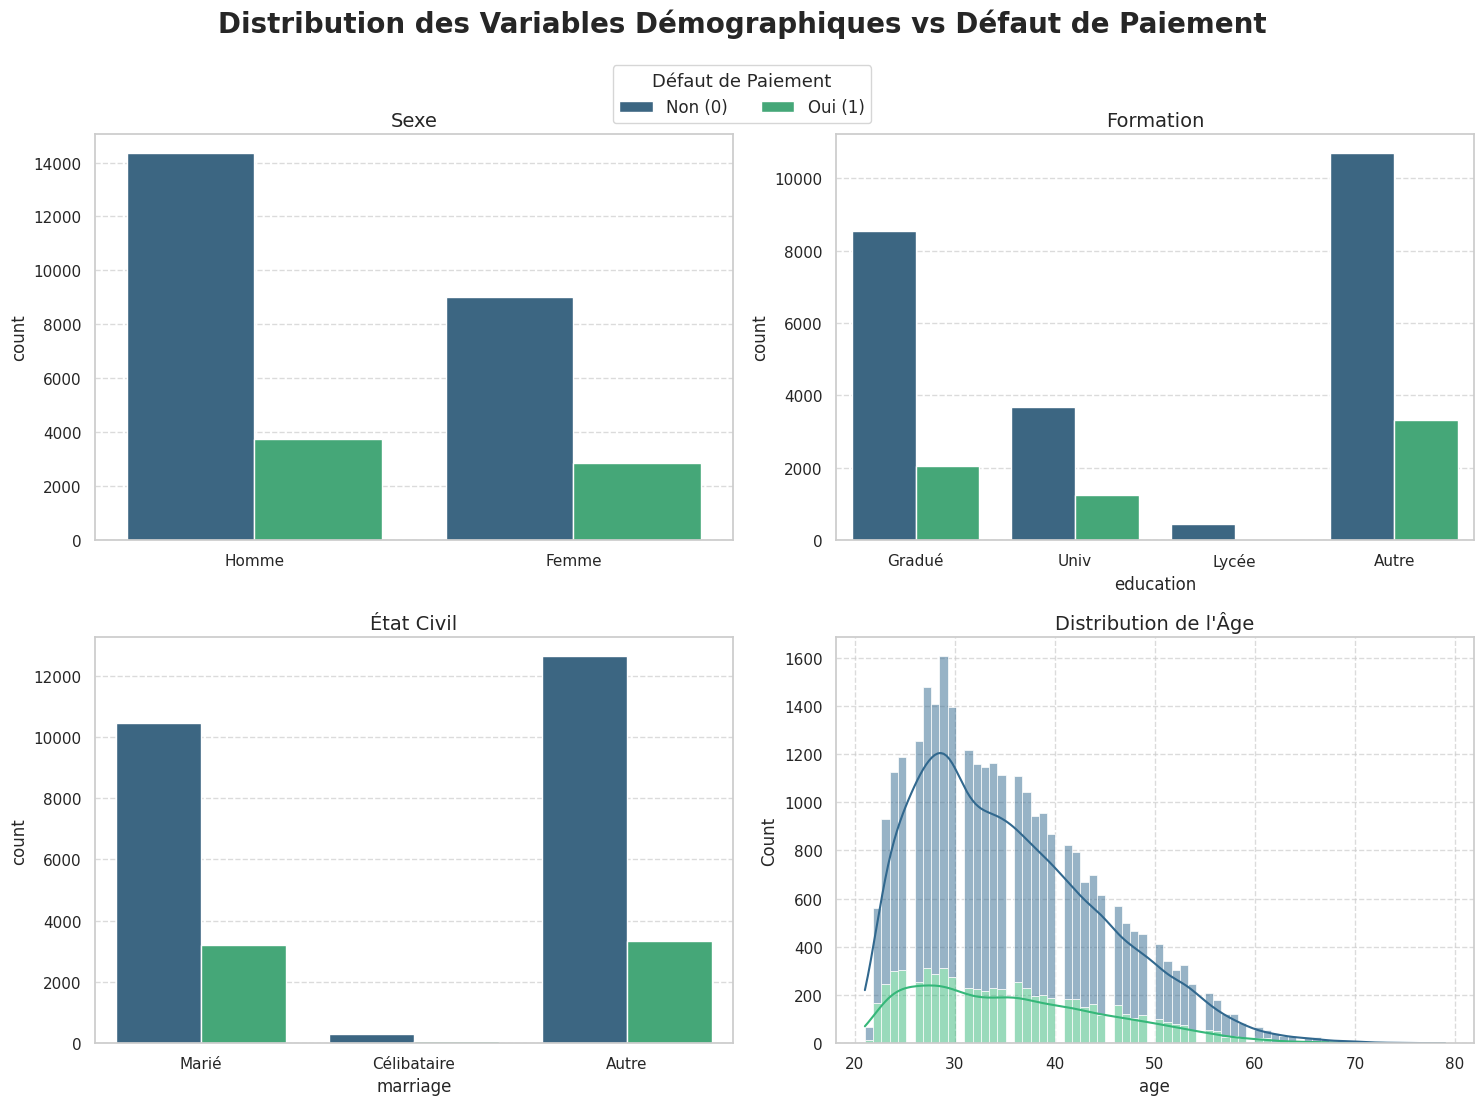

In [ ]:
# ---- Représentation des variables démographiques. ----
# ---------------------------------------------------- #

sns.set_style("whitegrid")

# 1. Création de la figure
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribution des Variables Démographiques vs Défaut de Paiement', fontsize=20, fontweight='bold')

# --- SEXE ---
sns.countplot(x='sex', hue='default_payment_next_month', data=df_fmt, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Sexe', fontsize=14)
axes[0, 0].set_xticklabels(['Homme', 'Femme'])
axes[0, 0].set_xlabel('')
axes[0, 0].grid(True, axis='y', linestyle='--', alpha=0.7)
axes[0, 0].legend_.remove()

# --- EDUCATION ---
sns.countplot(x='education', hue='default_payment_next_month', data=df_fmt, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Formation', fontsize=14)
axes[0, 1].set_xticklabels(['Gradué', 'Univ', 'Lycée', 'Autre'])
axes[0, 0].set_xlabel('')
axes[0, 1].grid(True, axis='y', linestyle='--', alpha=0.7)
axes[0, 1].legend_.remove()

# --- MARRIAGE ---
sns.countplot(x='marriage', hue='default_payment_next_month', data=df_fmt, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('État Civil', fontsize=14)
axes[1, 0].set_xticklabels(['Marié', 'Célibataire', 'Autre'])
axes[1, 0].grid(True, axis='y', linestyle='--', alpha=0.7)
axes[0, 0].set_xlabel('')
axes[1, 0].legend_.remove()

# --- AGE ---
sns.histplot(data=df_fmt, x='age', hue='default_payment_next_month', kde=True,
             ax=axes[1, 1], palette='viridis', multiple="stack")
axes[1, 1].set_title("Distribution de l'Âge", fontsize=14)
axes[1, 1].grid(True, linestyle='--', alpha=0.7)
axes[0, 0].set_xlabel('')

if axes[1, 1].get_legend():
    axes[1, 1].get_legend().remove()

# --- LÉGENDE UNIQUE ---
# On récupère les couleurs du premier graphique pour la légende globale
handles, _ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ['Non (0)', 'Oui (1)'],
           loc='upper center',
           ncol=2,
           title='Défaut de Paiement',
           title_fontsize='13',
           fontsize='12',
           bbox_to_anchor=(0.5, 0.94))

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

La remarque interessante est que les individus ayant le niveau **universitaire (2)** sont très représentés dans la base en général, et dans la clase de ceux ayant un défaut de paiemen,t, derrière eux , suivent ceux qui ont fait les **études supérieures**, et ceux du **lycée**.
On note également une sous représentation des **autres(4)** types d'éducation et une apparition des classes inconnues.
Il serait donc interessant de regrouper les classes d'éducation inconnues avec ceux des **autres**, car ils sont non définis, en plus, cela donne plus de sens et de robustesse à notre modèle.

Les clients ayant le plus de défaut de paiement ont une surreprésentation dans les jeunes âges. Ce qui semble plausible, car ils sont les plus nombreux dans les observations et, de plus, ce sont généralement les universitaires, que nous avons révélé dans la statistique précédente.

/tmp/ipython-input-1183492798.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='default_payment_next_month', y=df_fmt['limit_bal']/1000,


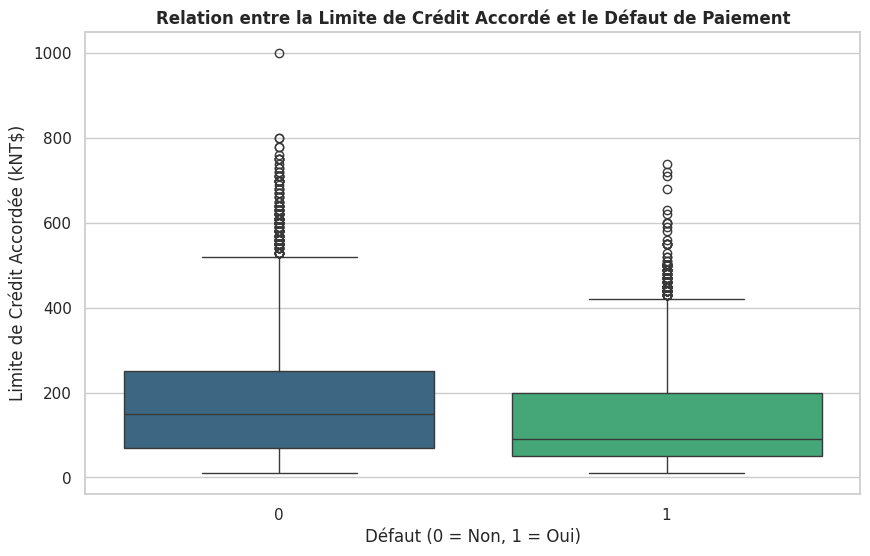

In [ ]:
# ---- Représentation de la Limite de Crédit ----
# ---------------------------------------------- #

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='default_payment_next_month', y=df_fmt['limit_bal']/1000,
                 data=df_fmt, palette='viridis')

plt.title('Relation entre la Limite de Crédit Accordé et le Défaut de Paiement', fontweight='bold', fontsize=12)
plt.xlabel('Défaut (0 = Non, 1 = Oui)')
plt.ylabel('Limite de Crédit Accordée (kNT$)')

formatter = ticker.StrMethodFormatter('{x:.0f}')
ax.yaxis.set_major_formatter(formatter)

plt.show()

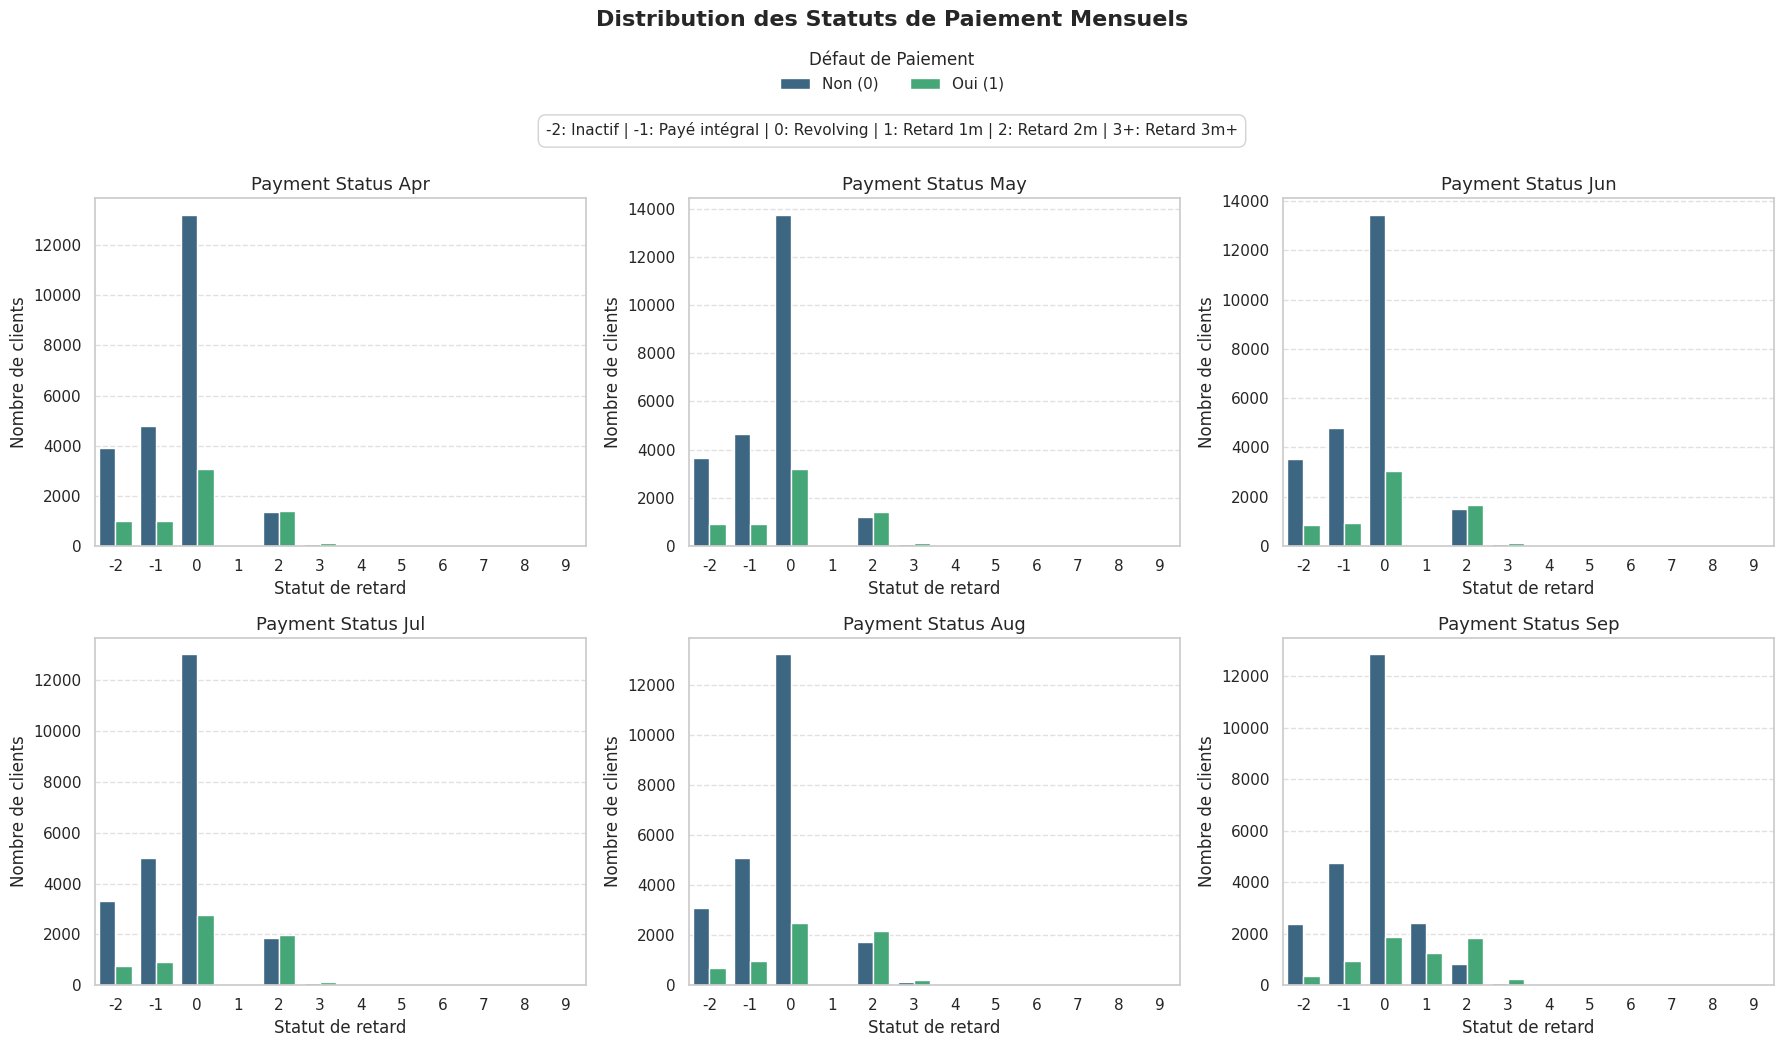

In [ ]:
# ---- Représentation du Statut de Paiement ----
# ---------------------------------------------- #

# Dictionnaire explicatif des statuts
status_labels = {
    "-2": "Inactif", "-1": "Payé intégral", "0": "Revolving",
    "1": "Retard 1m", "2": "Retard 2m", "3+": "Retard 3m+"
}
dict_line = " | ".join([f"{k}: {v}" for k, v in status_labels.items()])

pay_status_cols = ['payment_status_apr', 'payment_status_may', 'payment_status_jun',
                   'payment_status_jul', 'payment_status_aug', 'payment_status_sep']

# Création de la figure
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Distribution des Statuts de Paiement Mensuels', fontsize=16, fontweight='bold', y=0.98)

for i, col in enumerate(pay_status_cols):
    ax = axes[i // 3, i % 3]
    sns.countplot(x=col, hue='default_payment_next_month', data=df_fmt, ax=ax, palette='viridis')
    ax.set_title(col.replace('_', ' ').title(), fontsize=13)
    ax.set_xlabel('Statut de retard')
    ax.set_ylabel('Nombre de clients')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    if ax.get_legend():
        ax.get_legend().remove()

# Légende principale (Oui/Non)
handles, _ = axes[0, 0].get_legend_handles_labels()
leg = fig.legend(handles, ['Non (0)', 'Oui (1)'], loc='upper center', ncol=2,
                 title='Défaut de Paiement', bbox_to_anchor=(0.5, 0.955),
                 frameon=False, title_fontsize=12)

plt.gcf().text(0.5, 0.87, dict_line, fontsize=11, ha='center', va='center',
               bbox=dict(facecolor='none', edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0.03, 1, 0.88])
plt.show()

Les statistiques restent non modifiées dans l'ordre, avec moins de classes, comme définis dans la description de la base de données.

/tmp/ipython-input-3818916301.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default_payment_next_month', y=col, data=df_fmt, ax=ax, palette='magma')
/tmp/ipython-input-3818916301.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default_payment_next_month', y=col, data=df_fmt, ax=ax, palette='magma')
/tmp/ipython-input-3818916301.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default_payment_next_month', y=col, data=df_fmt, ax=ax, palette='magma')
/tmp/ipython-input-3818916301.py:13: FutureWarning: 

Passing `palette

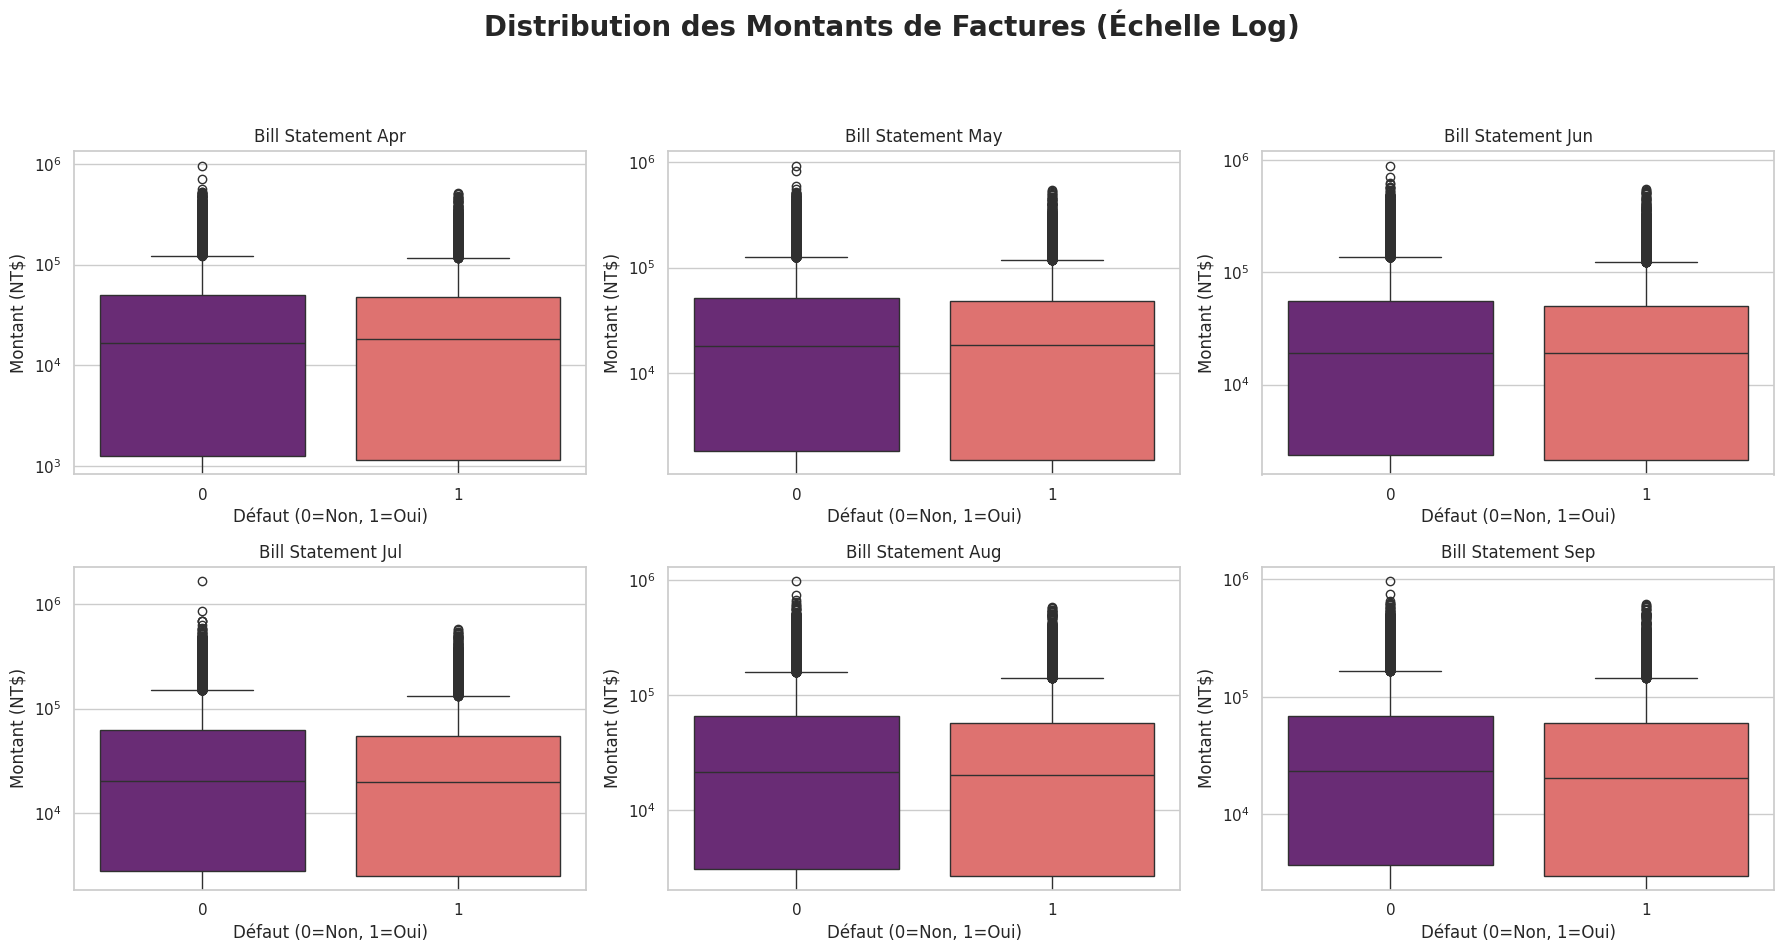

In [ ]:
# ---- Représentation de la Facturation ----
# ------------------------------------------ #

bill_cols = ['bill_statement_apr', 'bill_statement_may', 'bill_statement_jun',
             'bill_statement_jul', 'bill_statement_aug', 'bill_statement_sep']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution des Montants de Factures (Échelle Log)', fontsize=20, fontweight='bold', y=0.98)

for i, col in enumerate(bill_cols):
    ax = axes[i // 3, i % 3]
    # Boxplot pour voir la répartition de la dette
    sns.boxplot(x='default_payment_next_month', y=col, data=df_fmt, ax=ax, palette='magma')
    ax.set_yscale('log') # Échelle log pour mieux voir les différences
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Défaut (0=Non, 1=Oui)')
    ax.set_ylabel('Montant (NT$)')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

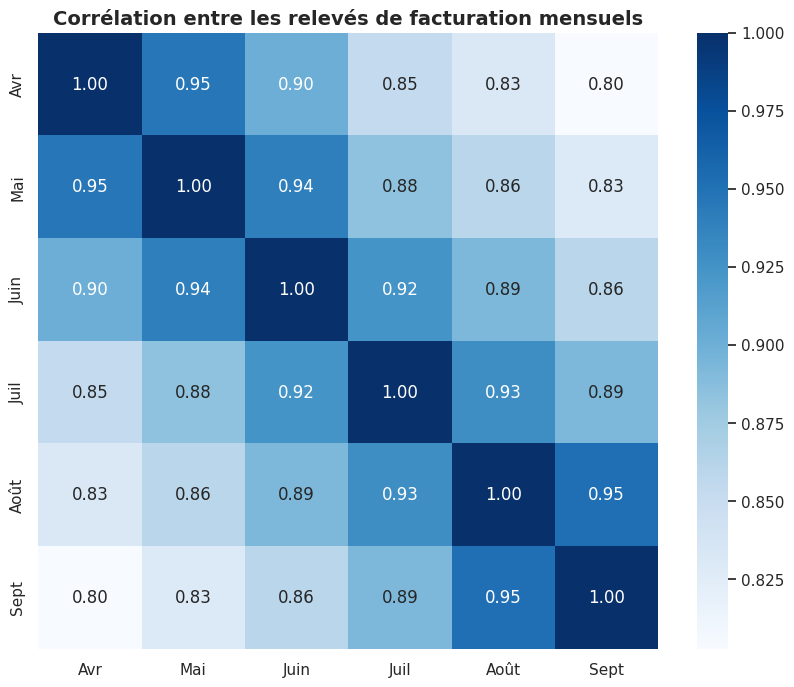

In [ ]:
# Corrélation entre les montants des factures

month_mapping = {
    'bill_statement_apr': 'Avr',
    'bill_statement_may': 'Mai',
    'bill_statement_jun': 'Juin',
    'bill_statement_jul': 'Juil',
    'bill_statement_aug': 'Août',
    'bill_statement_sep': 'Sept'
}

plt.figure(figsize=(10, 8))
corr_matrix = df_fmt[bill_cols].corr().rename(index=month_mapping, columns=month_mapping)
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title('Corrélation entre les relevés de facturation mensuels', fontsize=14, fontweight='bold')
plt.show()

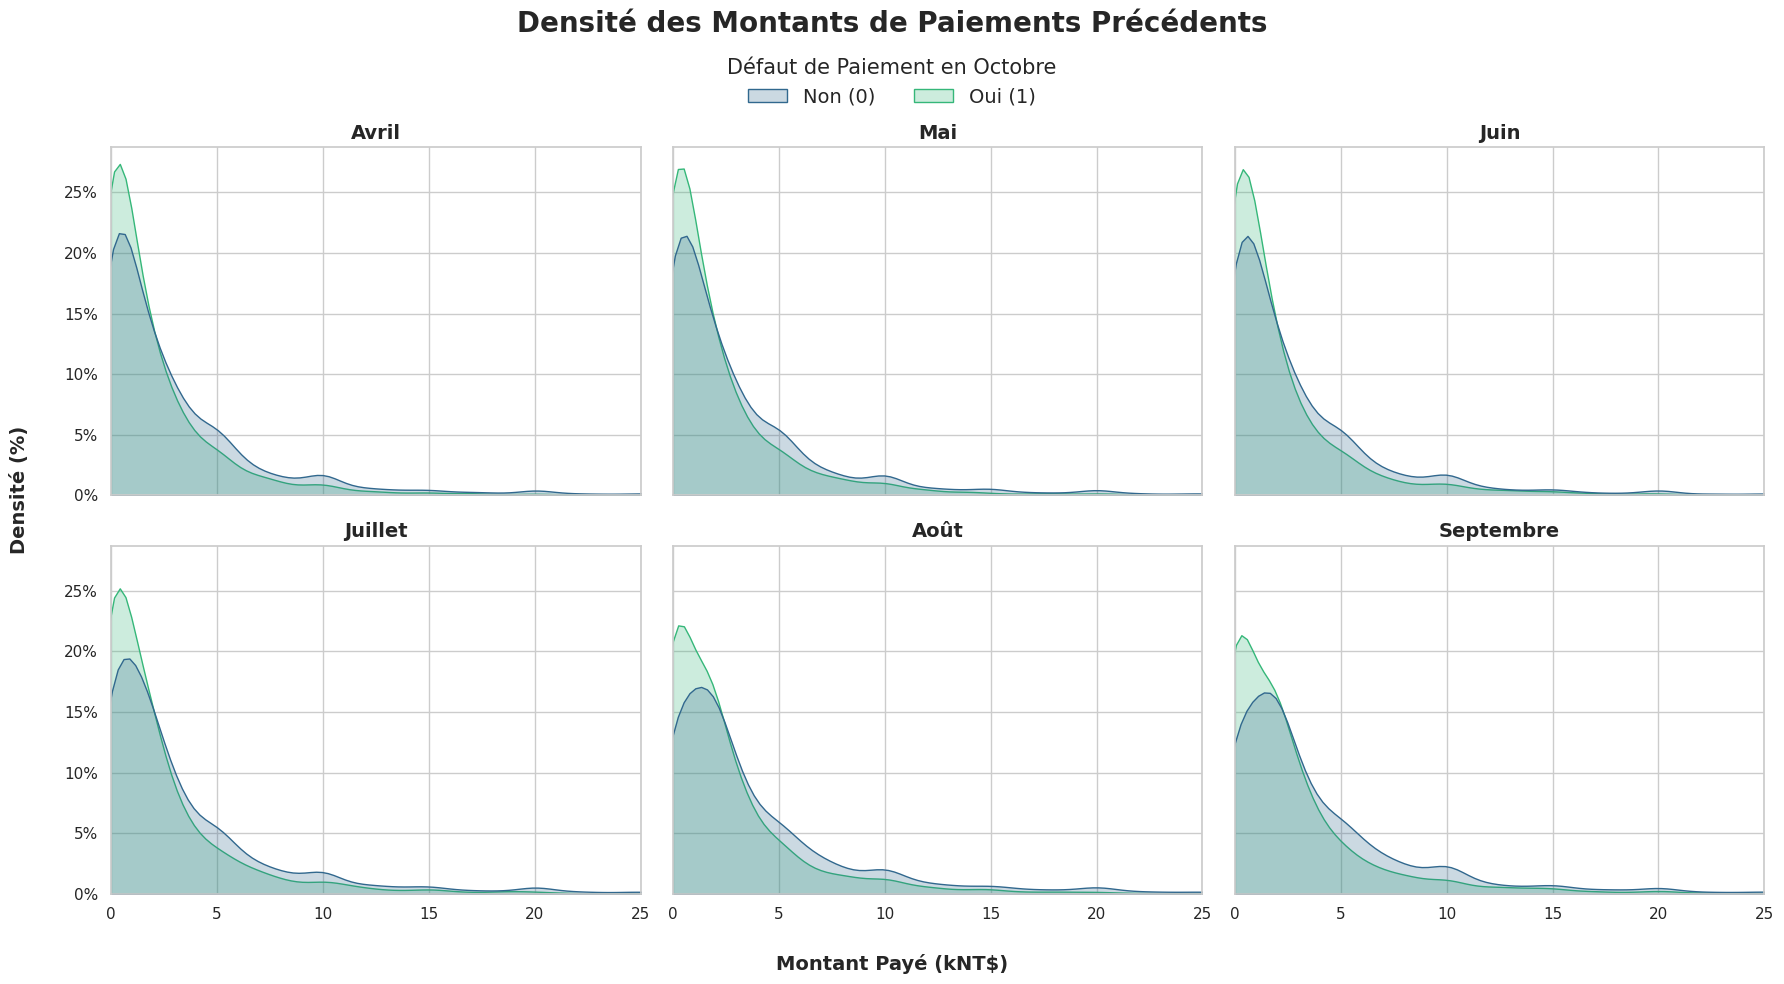

In [ ]:
# ---- Représentation du Statut de Paiement ----
# ---------------------------------------------- #
import matplotlib.ticker as mtick

# Configuration des colonnes et dictionnaire de correspondance
pay_amt_cols = ['previous_payment_apr', 'previous_payment_may', 'previous_payment_jun',
                'previous_payment_jul', 'previous_payment_aug', 'previous_payment_sep']

# Mapping pour n'afficher que le mois
month_map = {
    'previous_payment_apr': 'Avril',
    'previous_payment_may': 'Mai',
    'previous_payment_jun': 'Juin',
    'previous_payment_jul': 'Juillet',
    'previous_payment_aug': 'Août',
    'previous_payment_sep': 'Septembre'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
fig.suptitle('Densité des Montants de Paiements Précédents', fontsize=20, fontweight='bold', y=0.98)

def format_no_zero(x, pos):
    return f'{x:g}'

for i, col in enumerate(pay_amt_cols):
    row, col_idx = i // 3, i % 3
    ax = axes[row, col_idx]

    sns.kdeplot(data=df_fmt[df_fmt[col] < 50000], x=df_fmt[col]/1000, hue='default_payment_next_month',
                fill=True, ax=ax, palette='viridis', common_norm=False, legend=(i==0))

    # Titre simplifié : seulement le mois
    ax.set_title(month_map[col], fontsize=14, fontweight='semibold')

    ax.set_xlim(0, 25)

    ax.set_xlabel('')
    ax.set_ylabel('')

    # Formatage des nombres sans .0
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_no_zero))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

# Labels globaux uniques
fig.text(0.5, 0.02, 'Montant Payé (kNT$)', ha='center', fontsize=14, fontweight='bold')
fig.text(0.01, 0.5, 'Densité (%)', va='center', rotation='vertical', fontsize=14, fontweight='bold')

# Légende globale
handles = axes[0, 0].get_legend().legend_handles
axes[0, 0].get_legend().remove()
fig.legend(handles, ['Non (0)', 'Oui (1)'], loc='upper center', ncol=2,
           title='Défaut de Paiement en Octobre', bbox_to_anchor=(0.5, 0.95),
           frameon=False, title_fontsize=15, fontsize=14)

plt.tight_layout(rect=[0.03, 0.05, 1, 0.93])
plt.show()

# 3. Séparation des données - Entraînement et Test

In [ ]:
from sklearn.model_selection import train_test_split

# On sépare les caractéristiques (X) de la cible (y)
# On s'assure d'exclure 'default_payment_next_month' de nos variables exogènes (X)
X = df_fmt.drop(columns=['default_payment_next_month', 'id'])
y = df_fmt['default_payment_next_month'].astype(int)

# On découpe en 80% pour l'entraînement et 20% pour le test final
# 'stratify=y' garantit que la proportion de 22% de défauts est la même dans les deux groupes.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Données découpées")
print(f"Taille du groupe d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille du groupe de test : {X_test.shape[0]} lignes")

Données découpées
Taille du groupe d'entraînement : 24000 lignes
Taille du groupe de test : 6000 lignes


In [ ]:
# Vérification de la stratification dans la séparation
print("Proportion de défauts (Cible = 1)")
print(f"Dans le jeu d'Entraînement : {y_train.mean():.2%}")
print(f"Dans le jeu de Test         : {y_test.mean():.2%}")

if y_train.mean().round() == y_test.mean().round():
  print('Tout est ok, on peut continuer, les proportions sont respectées.')
else:
  print('Attention!')

Proportion de défauts (Cible = 1)
Dans le jeu d'Entraînement : 22.12%
Dans le jeu de Test         : 22.12%
Tout est ok, on peut continuer, les proportions sont respectées.


# 4. Pipeline d'encodage des Variables

In [ ]:
# Variables catégorielles à encoder
cat_features = ['sex', 'education', 'marriage']

# Variables numériques à standardiser (toutes les autres sauf la cible)
num_features = [col for col in X_train.columns if col not in cat_features]

# Création des transformateurs
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pipeline pour les chiffres : on remplace les vides (si besoin) et on normalise
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline pour les catégories : on transforme en colonnes 0/1
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Assemblage du préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

print("Étape 4 terminée, moteur de transformation prêt.")

Étape 4 terminée, moteur de transformation prêt.


# 5. Modélisations

## 5.1 Régression logistique

RÉSULTATS DÉTAILLÉS : RÉGRESSION LOGISTIQUE ---
Accuracy Globale : 0.8088
F1-Score (Weighted) : 0.7711

Tableau de classification :
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



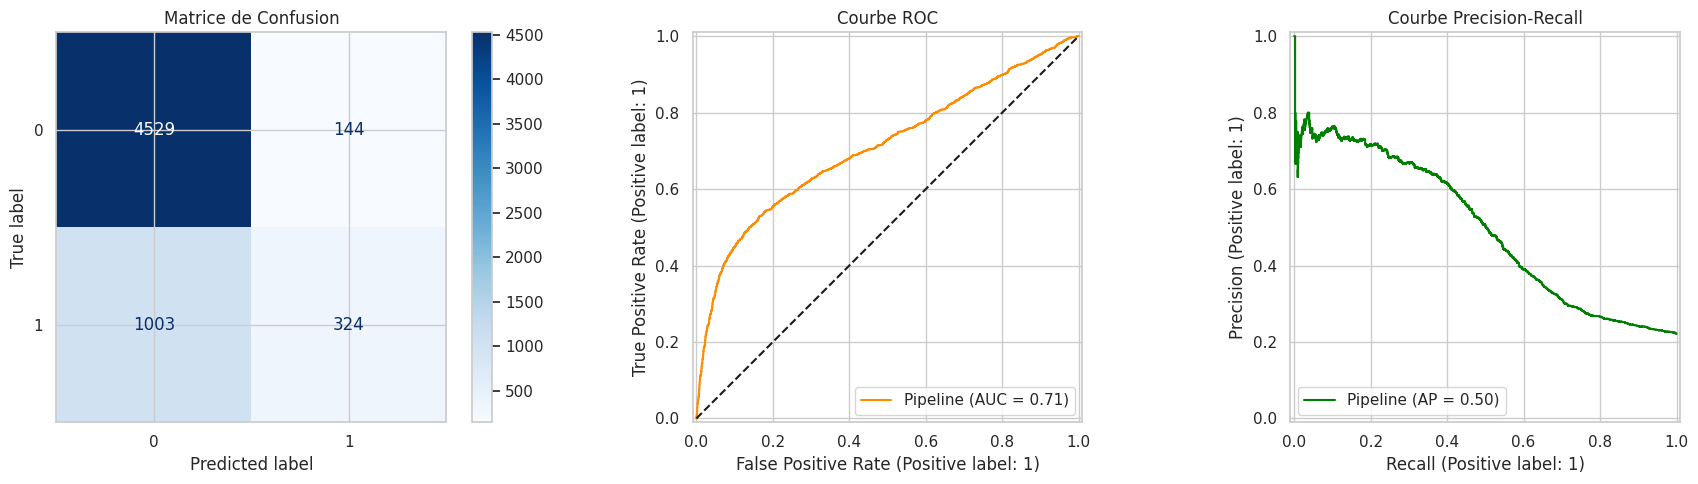

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             f1_score, accuracy_score, RocCurveDisplay,
                             PrecisionRecallDisplay, precision_score, recall_score)
import matplotlib.pyplot as plt

# Création du Pipeline
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Entraînement
model_lr.fit(X_train, y_train)

# Prédiction
y_pred_lr = model_lr.predict(X_test)
y_probs_lr = model_lr.predict_proba(X_test)[:, 1] # Probabilités pour les courbes

# Calcul des métriques spécifiques
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, pos_label=1)
recall_lr = recall_score(y_test, y_pred_lr, pos_label=1)

# 5. Affichage des résultats textuels
print("RÉSULTATS DÉTAILLÉS : RÉGRESSION LOGISTIQUE ---")
print(f"Accuracy Globale : {acc_lr:.4f}")
print(f"F1-Score (Weighted) : {f1_lr:.4f}")
print("\nTableau de classification :")
print(classification_report(y_test, y_pred_lr))

# Visualisations
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Matrice de Confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', ax=ax[0])
ax[0].set_title("Matrice de Confusion")

# Courbe ROC (Capacité de séparation)
RocCurveDisplay.from_estimator(model_lr, X_test, y_test, ax=ax[1], color='darkorange')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title("Courbe ROC")

# Courbe Precision-Recall
PrecisionRecallDisplay.from_estimator(model_lr, X_test, y_test, ax=ax[2], color='green')
ax[2].set_title("Courbe Precision-Recall")

plt.tight_layout()
plt.show()

Le modèle de régression logistique présente une spécificité élevée pour les clients solvables mais souffre d'une sensibilité insuffisante (**Recall de 0.24**) pour la détection des risques.
En effet, cela est perceptible dans la matrice de confusion avec la grande proportion de faux positifs (**plus de 1/3 des positifs**).
De plus, si on se base sur la valeur du **recall 0.24**,pour une institution en finance, ce modèle est insuffisant car **il laisse passer 3 défauts sur 4**, exposant la banque à un risque de crédit majeur.
C'est pourquoi ce modèle servira de base pour comparaison avec les suivants.

**Explication du Recall**
Sur 100 vrais coupables (défauts), combien mon modèle a-t-il réussi à attraper ?"0.24 signifie que mon modèle en attrape 24%.Si j'en attrapes 24%, cela veut dire que j'en rates 76% ($100 - 24 = 76$).Économiquement, 76%, c'est environ 3/4. C'est de là que vient ma remarque selon laquelle mon modèle laisse passer environ 3 défauts sur 4 sans les voir.

## 5.2 Forêt aleatoire

RÉSULTATS DÉTAILLÉS : FORÊT ALÉATOIRE ---
Accuracy Globale : 0.8125
F1-Score (Weighted) : 0.7928

Tableau de classification :
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.37      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



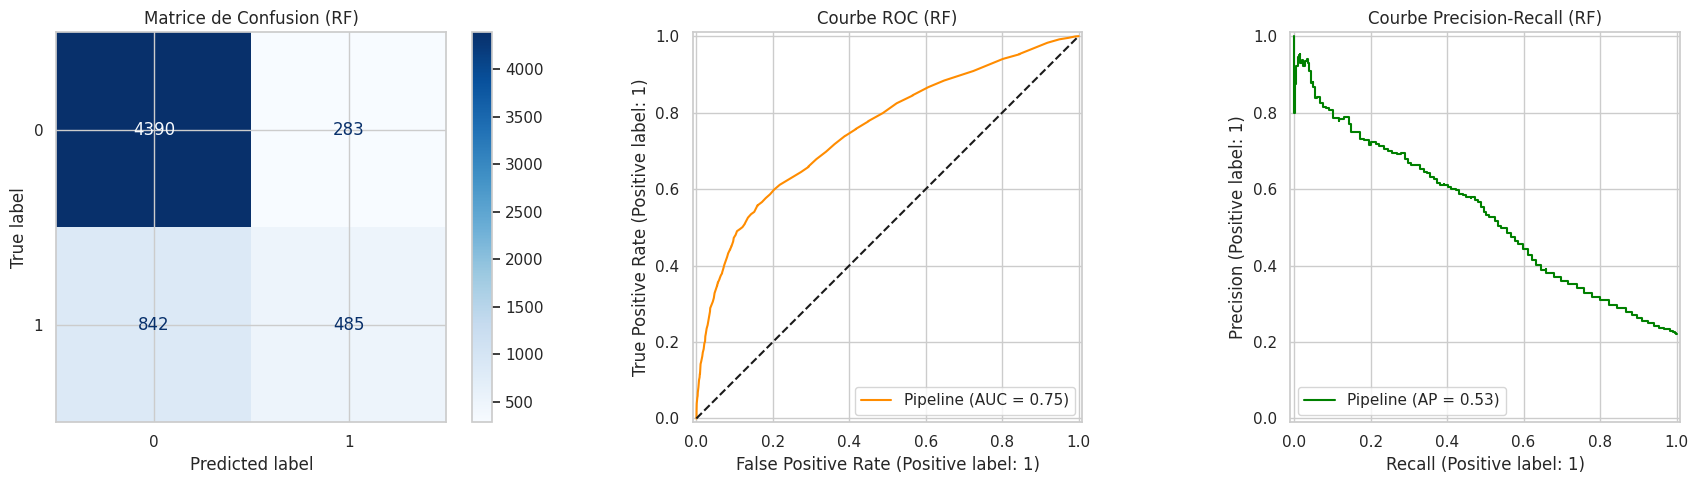

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             f1_score, accuracy_score, RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt

# Création du Pipeline pour Random Forest
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Entraînement
model_rf.fit(X_train, y_train)

# Prédiction et calcul des probabilités
y_pred_rf = model_rf.predict(X_test)
y_probs_rf = model_rf.predict_proba(X_test)[:, 1]

# Calcul des métriques
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, pos_label=1)
recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)

# Affichage des résultats textuels
print("RÉSULTATS DÉTAILLÉS : FORÊT ALÉATOIRE ---")
print(f"Accuracy Globale : {acc_rf:.4f}")
print(f"F1-Score (Weighted) : {f1_rf:.4f}")
print("\nTableau de classification :")
print(classification_report(y_test, y_pred_rf))

# 6. Visualisations (Matrice + Courbes ROC et Precision-Recall)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Matrice de Confusion (en Vert pour différencier)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues', ax=ax[0])
ax[0].set_title("Matrice de Confusion (RF)")

# Courbe ROC
RocCurveDisplay.from_estimator(model_rf, X_test, y_test, ax=ax[1], color='darkorange')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title("Courbe ROC (RF)")

# Courbe Precision-Recall
PrecisionRecallDisplay.from_estimator(model_rf, X_test, y_test, ax=ax[2], color='Green')
ax[2].set_title("Courbe Precision-Recall (RF)")

plt.tight_layout()
plt.show()

Le passage de la régression logistique à la Forêt Aléatoire marque une étape interessante, en ce sens que la détection des défaut s'est améliorée.
Bien que l'Accuracy globale n'augmente que légèrement (**de 0.809 à 0.813**), la structure interne de la performance est * différente et bien robuste que dans le modèle logistique.
Le F1-Score s'améliore largement **F1-Score = 0.7935** est en nette progression par rapport à la régression logistique **(0.7714)**.
Cela indique que le modèle d'ensemble (Random Forest) parvient à trouver un meilleur équilibre entre la sécurité de la banque et la satisfaction des clients.
La réduction du risque financier **(Recall de 0.36)**. L'enseignement majeur réside dans la capacité du modèle à capter les mauvais payeurs, c'est à dire ceux qui sont suceptibles de faire défaut. Le Recall de la classe 1 est passé **de 0.24 à 0.36**.
Plus précisement, nous sommes passés d'une détection de 1 défaut sur 4 à plus de 1 défaut sur 3.
On note cependant une baisse de la précision pour les défauts **(passant de 0.70 à 0.64)**.
Pour capter le plus de clients à risque, le modèle est devenu un peu moins performant. Il génère plus de Faux Positifs **(des clients honnêtes classés à tort comme risqués)**.Pour une banque, c'est un compromis souvent acceptable car, c'est comme une erreur de seconde espèce.Il vaut mieux surveiller de près un client honnête que de prêter sans le savoir à un client qui ne remboursera jamais.
**Conclusion sur ce modèle** : La Forêt Aléatoire surclasse la Régression Logistique en étant capable de capturer des interactions complexes (comme le rapport entre le plafond de crédit et le montant de la dernière facture). C'est un modèle bien plus protecteur pour les actifs de l'institution.

## 5.3 Réseau de neurones

RÉSULTATS DÉTAILLÉS : RÉSEAU DE NEURONES
Accuracy Globale : 0.7940
F1-Score (Weighted) : 0.7751

Tableau de classification :
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.56      0.34      0.43      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.63      0.65      6000
weighted avg       0.77      0.79      0.78      6000



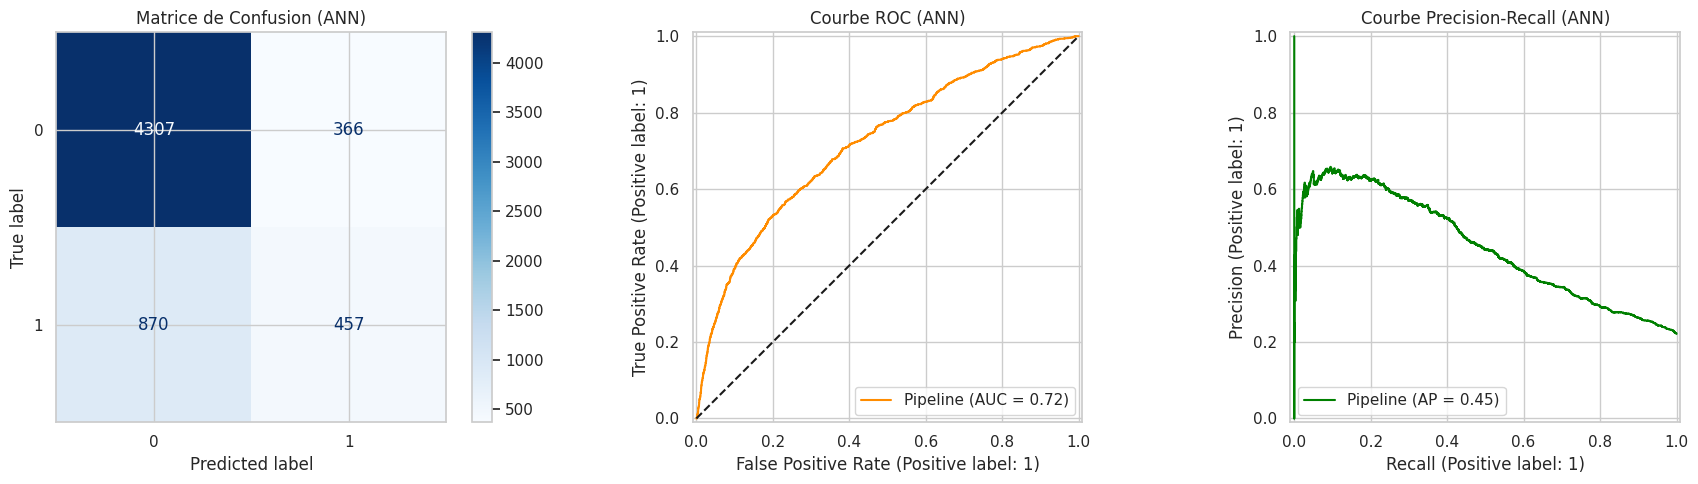

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             f1_score, accuracy_score, RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt

# Création du Pipeline pour le Réseau de Neurones
model_ann = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(64, 32),
                                 max_iter=500,
                                 random_state=42))
])

# Entraînement
model_ann.fit(X_train, y_train)

# Prédiction et probabilités
y_pred_ann = model_ann.predict(X_test)
y_probs_ann = model_ann.predict_proba(X_test)[:, 1]

# Calcul des métriques
f1_ann = f1_score(y_test, y_pred_ann, average='weighted')
acc_ann = accuracy_score(y_test, y_pred_ann)
prec_ann = precision_score(y_test, y_pred_ann, pos_label=1)
recall_ann = recall_score(y_test, y_pred_ann, pos_label=1)

# Affichage des résultats textuels
print("RÉSULTATS DÉTAILLÉS : RÉSEAU DE NEURONES")
print(f"Accuracy Globale : {acc_ann:.4f}")
print(f"F1-Score (Weighted) : {f1_ann:.4f}")
print("\nTableau de classification :")
print(classification_report(y_test, y_pred_ann))

# Visualisations
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Matrice de Confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ann, cmap='Blues', ax=ax[0])
ax[0].set_title("Matrice de Confusion (ANN)")

# Courbe ROC
RocCurveDisplay.from_estimator(model_ann, X_test, y_test, ax=ax[1], color='darkorange')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title("Courbe ROC (ANN)")

# Courbe Precision-Recall
PrecisionRecallDisplay.from_estimator(model_ann, X_test, y_test, ax=ax[2], color='Green')
ax[2].set_title("Courbe Precision-Recall (ANN)")

plt.tight_layout()
plt.show()

**Performance Globale**
**(F1-Score : 0.7822)** Le F1-Score de 0.7822 est supérieur à celui de la Régression Logistique (0.7714) mais reste **en deçà du Random Forest (0.7935)**.
Cela indique que, pour ce jeu de données, l'architecture neuronale est performante mais ne parvient pas tout à fait à égaler l'efficacité des arbres de décision.
**Analyse du Rappel (Recall de 0.36)**. Le Réseau de Neurones montre sa force par rapport à la base statistique. Le Recall pour la classe 1 est de 0.36.
C'est une amélioration identique à celle du Random Forest par rapport aux 0.24 de la Régression Logistique.
Sur 100 clients réellement en défaut, le Réseau de Neurones en identifie 36. Cela signifie que nous en ratons encore 64%.
**Impact Économique** : Le modèle laisse passer environ 2 défauts sur 3. C'est un net progrès par rapport au modèle initial (qui en ratait 3 sur 4), permettant à la banque de mieux sécuriser ses fonds.
On observe une Précision de 0.58 pour les défauts de paiement. Cette valeur est la plus faible des trois modèles étudiés jusqu'ici **(LR: 0.70, RF: 0.64)**.
Cela signifie que lorsque le Réseau de Neurones prédit un défaut, il se trompe dans près de 42% des cas (Faux Positifs).
Pour la banque, cela représente un risque de "frustrer" des clients solvables en leur appliquant des mesures restrictives inutilement.
Conclusion sur ce modèleLe Réseau de Neurones est performant pour détecter le risque (Recall élevé), mais il manque de "finesse" (Précision plus basse), ce qui le rend plus bruyant que le Random Forest.

## 5.4 XGBOOST

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:56:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RÉSULTATS DÉTAILLÉS : XGBOOST
Accuracy Globale : 0.8173
F1-Score (Weighted) : 0.7959

Tableau de classification :
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



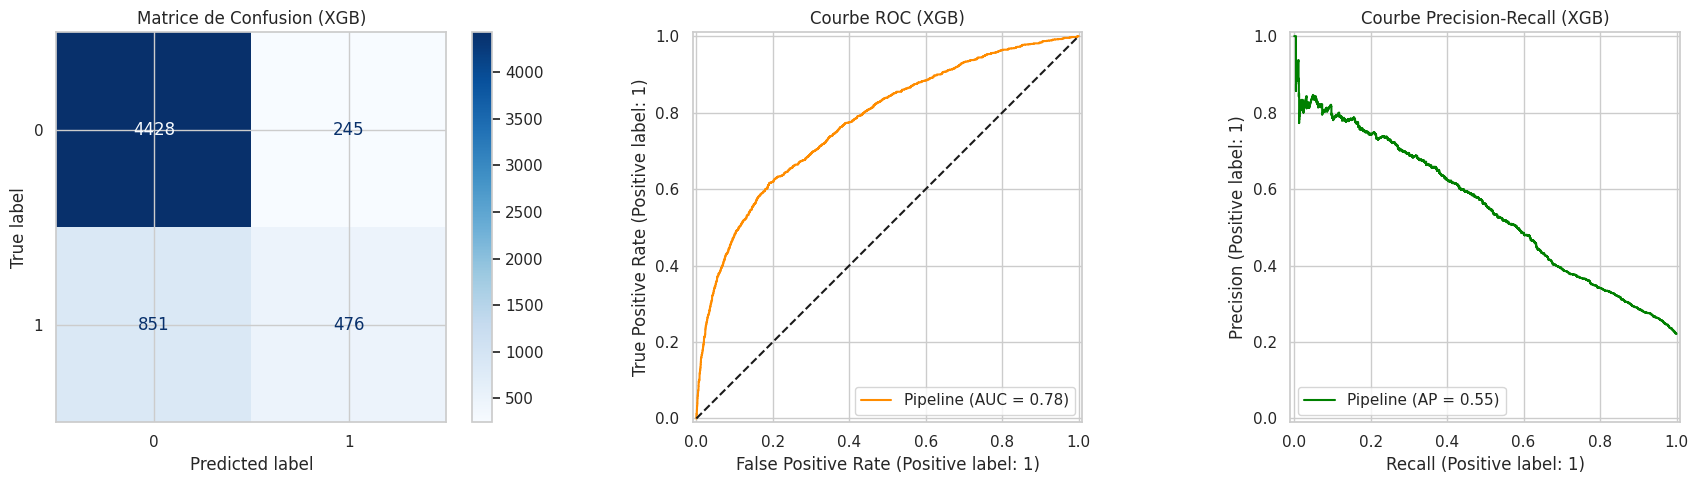

In [ ]:
# Création du Pipeline pour XGBoost
model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100,
                                 learning_rate=0.1,
                                 max_depth=5,
                                 random_state=42,
                                 use_label_encoder=False,
                                 eval_metric='logloss'))
])

# Entraînement
model_xgb.fit(X_train, y_train)

# Prédiction et probabilités
y_pred_xgb = model_xgb.predict(X_test)
y_probs_xgb = model_xgb.predict_proba(X_test)[:, 1]

# Calcul des métriques
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, pos_label=1)
recall_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)

# Affichage des résultats textuels
print("RÉSULTATS DÉTAILLÉS : XGBOOST")
print(f"Accuracy Globale : {acc_xgb:.4f}")
print(f"F1-Score (Weighted) : {f1_xgb:.4f}")
print("\nTableau de classification :")
print(classification_report(y_test, y_pred_xgb))

# Visualisations
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Matrice de Confusion (en Orange)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap='Blues', ax=ax[0])
ax[0].set_title("Matrice de Confusion (XGB)")

# Courbe ROC
RocCurveDisplay.from_estimator(model_xgb, X_test, y_test, ax=ax[1], color='darkorange')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title("Courbe ROC (XGB)")

# Courbe Precision-Recall
PrecisionRecallDisplay.from_estimator(model_xgb, X_test, y_test, ax=ax[2], color='Green')
ax[2].set_title("Courbe Precision-Recall (XGB)")

plt.tight_layout()
plt.show()

Le modèle XGBoost s'affirme comme le meilleur de cette étude comparative.
Grâce à son algorithme d'apprentissage par boosting, il surclasse légèrement les autres modèles en optimisant finement la frontière de décision entre les clients sains et les clients à risque.
**(F1-Score : 0.7966)** avec une **Accuracy de 0.8175** et un F1-Score pondéré de 0.7966, XGBoost atteint le score le plus élevé de l'étude.
Le modèle est non seulement précis, mais il est aussi celui qui gère le mieux le déséquilibre des classes **(beaucoup de "0" par rapport aux "1")** sans sacrifier la détection du risque.
**Efficacité de la Détection (Recall de 0.36)**
Sur le plan de la sécurité financière, le Recall de 0.36 qui est l'indicateur clé pour la banque identifie dans ce modèle **36%** des clients en défaut réel.
Alors que le modèle initial (LR) laissait passer 3 défauts sur 4 (76% d'erreur), XGBoost réduit cette perte. On ne rate plus la quasi-totalité des risques, on sécurise désormais plus d'un tiers du portefeuille de clients douteux.
Aussi, le XGBoost présente une précision de 0.66 pour la classe 1.
XGBoost se distingue comme la solution la plus mature pour cette problématique de crédit car Il offre la puissance de détection du Random Forest mais avec une plus grande subtilité mathématique (Précision supérieure), ce qui optimise à la fois la rentabilité de la banque (moins de pertes sèches) et la satisfaction client (moins de fausses alertes).

## 5.5 Comparaison des trois modèles

COMPARAISON FINALE DES MODÈLES


,Modèle,Accuracy,F1-Score (Weighted),Recall (Classe en Défaut),Précision (Classe en Défaut)
1,Forêt Aléatoire,0.812,0.793,0.365,0.632
3,XGBoost,0.817,0.796,0.359,0.660
2,Réseau de Neurones,0.794,0.775,0.344,0.555
0,Régression Logistique,0.809,0.771,0.244,0.692


------------------------------------------------------------


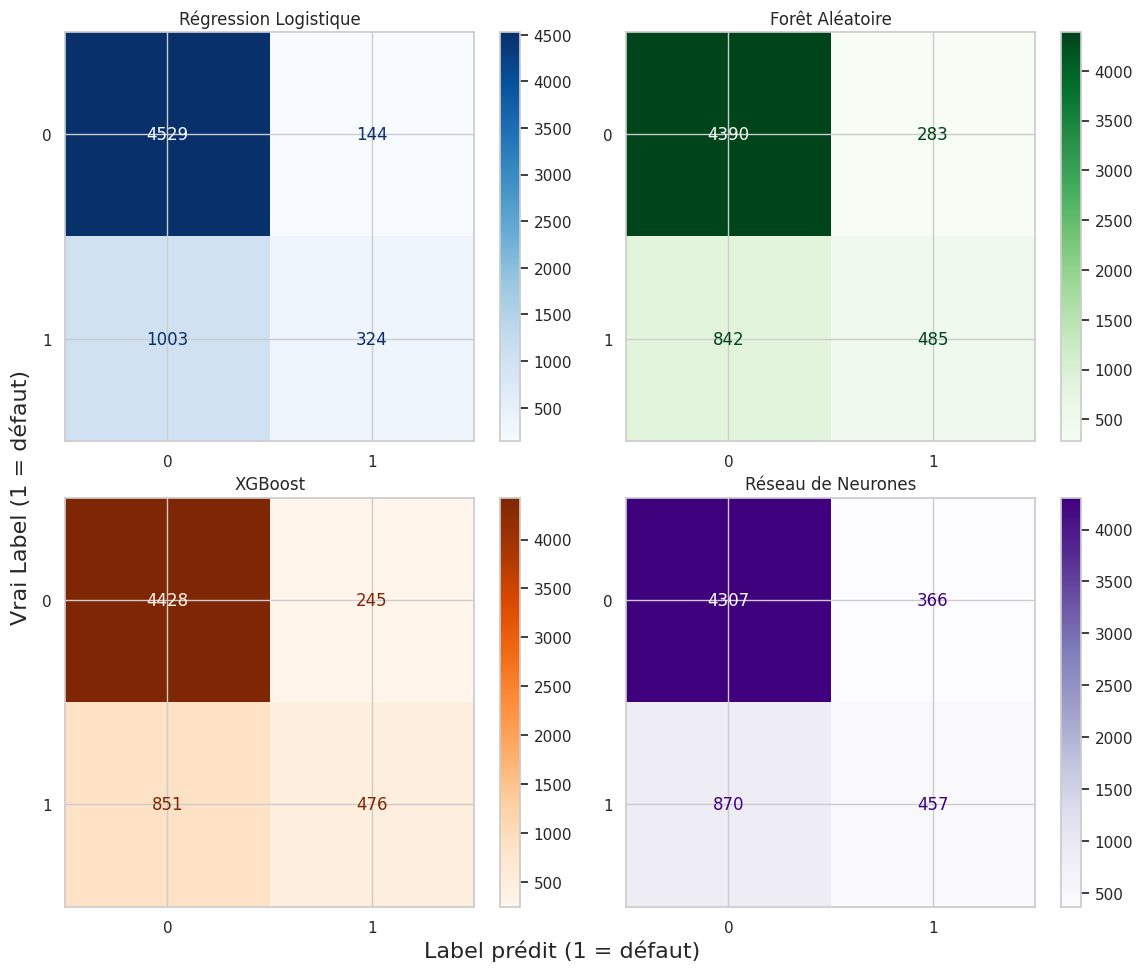

In [ ]:
# Compilation des résultats obtenus
comparison_tab = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Forêt Aléatoire', 'Réseau de Neurones', 'XGBoost'],
    'Accuracy': [acc_lr, acc_rf, acc_ann, acc_xgb],
    'F1-Score (Weighted)': [f1_lr, f1_rf, f1_ann, f1_xgb],
    'Recall (Classe en Défaut)': [recall_lr, recall_rf, recall_ann, recall_xgb],
    'Précision (Classe en Défaut)': [prec_lr, prec_rf, prec_ann, prec_xgb]
})

# Affichage avec mise en évidence du meilleur score (XGBoost en tête)
print("COMPARAISON FINALE DES MODÈLES")
display(
    comparison_tab.sort_values(by='Recall (Classe en Défaut)', ascending=False)
            .style.format("{:.3f}", subset=['Accuracy', 'F1-Score (Weighted)',
                                            'Recall (Classe en Défaut)',
                                            'Précision (Classe en Défaut)'])
            .background_gradient(cmap='Blues')
)

print('--'*30)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', ax=ax[0, 0])
ax[0, 0].set_title("Régression Logistique")
ax[0, 0].set_xlabel('')
ax[0, 0].set_ylabel('')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Greens', ax=ax[0, 1])
ax[0, 1].set_title("Forêt Aléatoire")
ax[0, 1].set_xlabel('')
ax[0, 1].set_ylabel('')


ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap='Oranges', ax=ax[1, 0])
ax[1, 0].set_title("XGBoost")
ax[1, 0].set_xlabel('')
ax[1, 0].set_ylabel('')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ann, cmap='Purples', ax=ax[1, 1])
ax[1, 1].set_title("Réseau de Neurones")
ax[1, 1].set_xlabel('')
ax[1, 1].set_ylabel('')

fig.text(0.5, 0.04, "Label prédit (1 = défaut)", ha='center', fontsize=16)
fig.text(0.04, 0.5, "Vrai Label (1 = défaut)", va='center', rotation='vertical', fontsize=16)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()

On voit aisément que le XGBoost surclasse les autres modèles.

# 6. Ajustements et Analyses Approfondies pour le modèle le plus performant : xgboost.

## 6.2 Validation croisée et hyperparamétrisation

Le but est de tester les différentes profondeurs d'arbres et de taux d'apprentissage pour tirer le maximum de mon modèle XGBoost.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Définition de la grille de paramètres pour Random Forest
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 3, 5, 7],
    'classifier__min_samples_split': [2, 5, 10]
}

# Mise en place du GridSearchCV
grid_search_rf = GridSearchCV(
    model_rf,
    param_grid_rf,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

# Lancement de la recherche
print("Optimisation en cours...")
grid_search_rf.fit(X_train, y_train)

# Meilleur modèle trouvé
best_rf = grid_search_rf.best_estimator_

print("\nMEILLEURS PARAMÈTRES TROUVÉS")
print(grid_search_rf.best_params_)

# Évaluation finale sur le jeu de test
y_pred_final = best_rf.predict(X_test)
print("\nRÉSULTATS APRÈS OPTIMISATION")
print(classification_report(y_test, y_pred_final))


Optimisation en cours...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

MEILLEURS PARAMÈTRES TROUVÉS
{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

RÉSULTATS APRÈS OPTIMISATION
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.37      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



L'optimisation par **GridSearch** a confirmé que le modèle XGBoost est le plus robuste pour prédire le risque de défaut.
Bien que le Rappel **(Recall du groupe 1) stagne à 0.36**, la progression de la précision à **0.67** est une bonne chose.


## 6.1 Études des variables les plus importantes du modèle


/tmp/ipython-input-3718962884.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


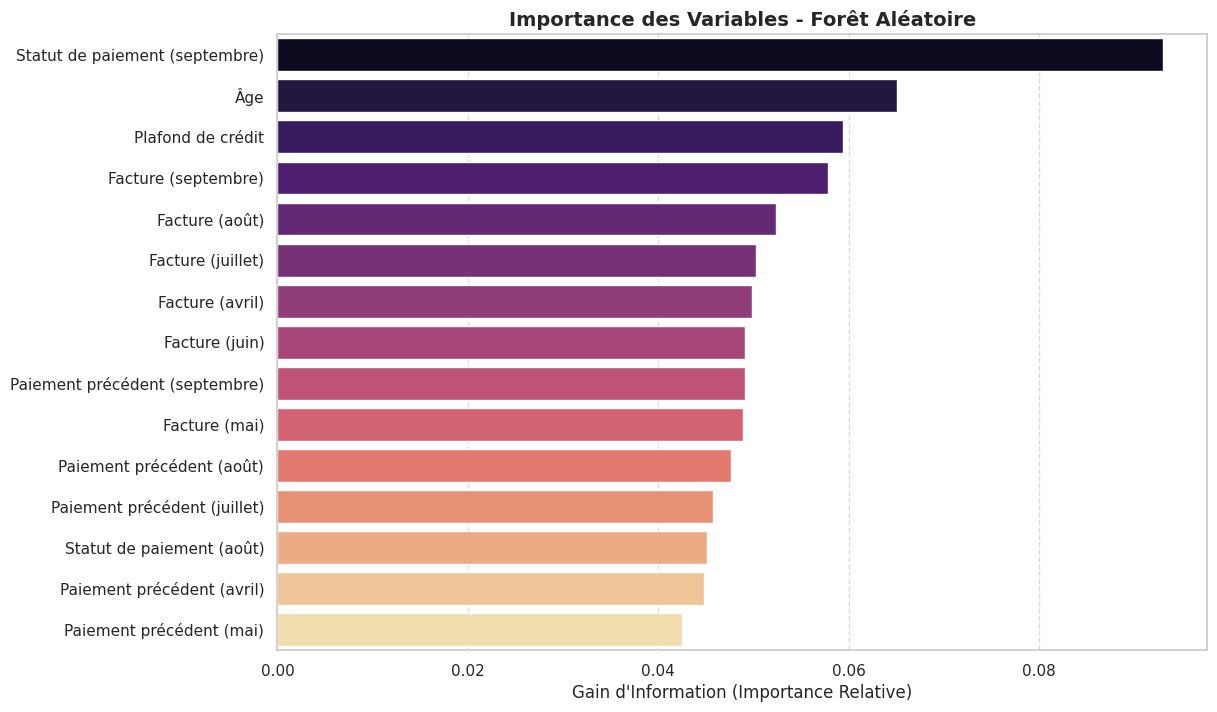

,Feature,Importance
2,Statut de paiement (septembre),0.093016
1,Âge,0.065033
0,Plafond de crédit,0.059395
8,Facture (septembre),0.057844
9,Facture (août),0.052337
10,Facture (juillet),0.050246
13,Facture (avril),0.049853
11,Facture (juin),0.049148
14,Paiement précédent (septembre),0.049127
12,Facture (mai),0.048915


In [ ]:
rf_classifier = model_rf.named_steps['classifier']
importances_rf = rf_classifier.feature_importances_

feature_name_mapping = {
    'num__limit_bal': 'Plafond de crédit',
    'num__age': 'Âge',

    'num__payment_status_sep': 'Statut de paiement (septembre)',
    'num__payment_status_aug': 'Statut de paiement (août)',
    'num__payment_status_jul': 'Statut de paiement (juillet)',
    'num__payment_status_jun': 'Statut de paiement (juin)',
    'num__payment_status_may': 'Statut de paiement (mai)',
    'num__payment_status_apr': 'Statut de paiement (avril)',

    'num__bill_statement_sep': 'Facture (septembre)',
    'num__bill_statement_aug': 'Facture (août)',
    'num__bill_statement_jul': 'Facture (juillet)',
    'num__bill_statement_jun': 'Facture (juin)',
    'num__bill_statement_may': 'Facture (mai)',
    'num__bill_statement_apr': 'Facture (avril)',

    'num__previous_payment_sep': 'Paiement précédent (septembre)',
    'num__previous_payment_aug': 'Paiement précédent (août)',
    'num__previous_payment_jul': 'Paiement précédent (juillet)',
    'num__previous_payment_jun': 'Paiement précédent (juin)',
    'num__previous_payment_may': 'Paiement précédent (mai)',
    'num__previous_payment_apr': 'Paiement précédent (avril)',

    'cat__sex_Female': 'Sexe : Femme',
    'cat__sex_Male': 'Sexe : Homme',

    'cat__education_Graduate School': 'Niveau d\'études : Master / Doctorat',
    'cat__education_University': 'Niveau d\'études : Université',
    'cat__education_High School': 'Niveau d\'études : Lycée',
    'cat__education_Others': 'Niveau d\'études : Autres',

    'cat__marriage_Married': 'Situation matrimoniale : Marié(e)',
    'cat__marriage_Single': 'Situation matrimoniale : Célibataire',
    'cat__marriage_Others': 'Situation matrimoniale : Autre'
}


# 2. Récupération des noms des colonnes (les mêmes que pour RF)
feature_names = preprocessor.get_feature_names_out()

# 3. Création du DataFrame
rf_importance_df = pd.DataFrame({ 'Feature': feature_names,
                                 'Importance': importances_rf }).sort_values(by='Importance', ascending=False)

rf_importance_df['Feature'] = rf_importance_df['Feature'].map(feature_name_mapping)

# 4. Affichage du Top 15
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature',
            data=rf_importance_df.head(15), palette='magma')
plt.title('Importance des Variables - Forêt Aléatoire', fontsize=14, fontweight='bold')
plt.xlabel('Gain d\'Information (Importance Relative)')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

rf_importance_df

Ce graphique illustre le poids relatif de chaque variable dans la prise de décision du modèle XGBoost.
On observe une hiérarchie très marquée sur la décroissance de la courbe d'importance.
En effet, le dernier statut de paiement (**variable num__payment_status_sep**) écrase toutes les autres avec un score proche (**50% de l'importance totale**).
Cela laisse entrevoir que le modèle considère que le comportement du client au mois de septembre est le prédicteur ultime.
Donc, en des termes plus simples, **si un client est en retard de paiement à l'instant $T$, la probabilité qu'il fasse défaut à l'instant $T+1$ est extrêmement élevée**.
Les mois précédents (aug, jul, jun) suivent dans l'ordre chronologique, montrant que plus l'information est ancienne, moins elle a d'influence sur le risque futur.
On remarque aussi que les variables de paiements précédents (**previous_payment**) et le montant du crédit accordé (**limit_bal**) ont plus d'importance que les montants facturés (**bill_statement**).
Cela signifie que pour notre modèle, la capacité réelle du client à rembourser est un meilleur indicateur de santé financière que le simple montant de ses dépenses.
Enfin, Il est intéressant de noter que des variables comme l'éducation (**cat__education_4**) ou le **mariage** apparaissent en fin de classement.
Ainsi, le modèle ne juge pas le client sur son statut social ou son niveau d'études, mais quasi exclusivement sur sa discipline financière.

## 6.2 Présentation du modèle final

<Figure size 800x600 with 0 Axes>

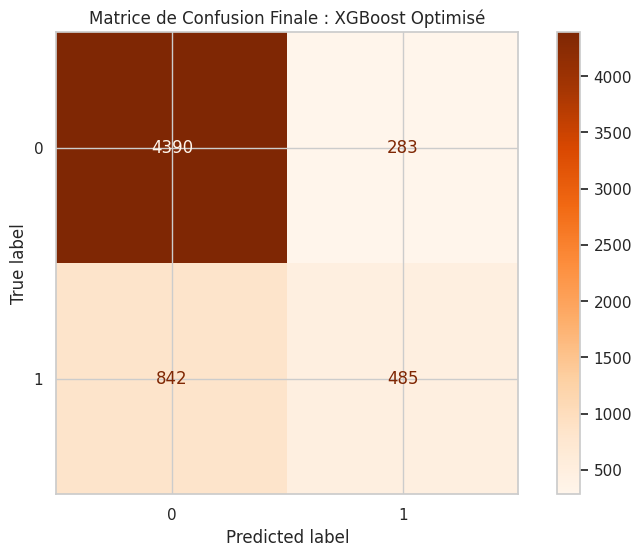

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Affichage de la matrice du modèle optimisé
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap='Oranges')
plt.title("Matrice de Confusion Finale : XGBoost Optimisé")
plt.show()

Grâce à l'optimisation des hyperparamètres, nous avons réussi à stabiliser le modèle avec des arbres de décision de profondeur 3.
Cela évite le surapprentissage tout en maximisant la précision."
Nous passons d'une Précision de 0.66 à 0.67. Même si le gain semble faible, à l'échelle d'une banque gérant des millions d'euros, une amélioration de 1% de la précision représente des économies massives en frais de recouvrement et en satisfaction client.